<a href="https://colab.research.google.com/github/zainazeem41472/Rice-Leaf-Disease-Classification/blob/main/HybridCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
!pip install tensorflow matplotlib scikit-learn

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [10]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
TRAIN_DIR = "/content/drive/MyDrive/RiceLeafDisease12classes/train"
VAL_DIR   = "/content/drive/MyDrive/RiceLeafDisease12classes/validation"



In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.3,
    shear_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7,1.3]
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Classes:", train_generator.class_indices)

Found 11996 images belonging to 12 classes.
Found 1413 images belonging to 12 classes.
Classes: {'Hispa': 0, 'Ragged Stunt Virus': 1, 'Sheath Rot': 2, 'Stem Rot': 3, 'Tungro': 4, 'bacterial_leaf_blight': 5, 'brown_spot': 6, 'healthy': 7, 'irrelevant_pics': 8, 'leaf_blast': 9, 'leaf_scald': 10, 'narrow_brown_spot': 11}


In [12]:
def cbam_block(x):
    # Channel Attention
    channel = GlobalAveragePooling2D()(x)
    channel = Dense(x.shape[-1]//8, activation='relu')(channel)
    channel = Dense(x.shape[-1], activation='sigmoid')(channel)
    channel = Reshape((1,1,x.shape[-1]))(channel)
    x = Multiply()([x, channel])

    # Spatial Attention
    spatial = Conv2D(1, (7,7), padding='same', activation='sigmoid')(x)
    x = Multiply()([x, spatial])

    return x

In [13]:
def residual_block(x, filters):
    shortcut = x

    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, padding='same')(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x

In [14]:
def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = MaxPooling2D()(x)

    x = residual_block(x, 64)
    x = cbam_block(x)
    x = MaxPooling2D()(x)

    x = residual_block(x, 128)
    x = cbam_block(x)
    x = MaxPooling2D()(x)

    x = residual_block(x, 256)
    x = cbam_block(x)

    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

In [15]:
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        pt = tf.exp(-ce)
        return alpha * (1 - pt)**gamma * ce
    return loss

In [16]:
model = build_model((224,224,3), train_generator.num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=focal_loss(),
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 112, 112,  │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ activation_1[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        576 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 112, 112,  │          0 │ activation_1[0][… │
│                     │ 64)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 112, 112,  │      3,137 │ multiply[0][0]    │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 112, 112,  │          0 │ multiply[0][0], 

 Total params: 1,355,271 (5.17 MB)

 Trainable params: 1,352,967 (5.16 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [17]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.3),
    tf.keras.callbacks.ModelCheckpoint("/content/drive/MyDrive/best_model.h5", save_best_only=True)
]

In [18]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=150,
    callbacks=callbacks
)

Epoch 1/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.3716 - loss: 0.3390 

375/375 ━━━━━━━━━━━━━━━━━━━━ 5356s 14s/step - accuracy: 0.4849 - loss: 0.2533 - val_accuracy: 0.0573 - val_loss: 0.4949 - learning_rate: 1.0000e-04
Epoch 2/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - accuracy: 0.6374 - loss: 0.1574

375/375 ━━━━━━━━━━━━━━━━━━━━ 255s 680ms/step - accuracy: 0.6591 - loss: 0.1439 - val_accuracy: 0.4742 - val_loss: 0.2845 - learning_rate: 1.0000e-04
Epoch 3/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 251s 668ms/step - accuracy: 0.7162 - loss: 0.1137 - val_accuracy: 0.5683 - val_loss: 0.4079 - learning_rate: 1.0000e-04
Epoch 4/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.7549 - loss: 0.0934

375/375 ━━━━━━━━━━━━━━━━━━━━ 248s 661ms/step - accuracy: 0.7654 - loss: 0.0897 - val_accuracy: 0.8429 - val_loss: 0.0581 - learning_rate: 1.0000e-04
Epoch 5/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 249s 664ms/step - accuracy: 0.7945 - loss: 0.0768 - val_accuracy: 0.8209 - val_loss: 0.0601 - learning_rate: 1.0000e-04
Epoch 6/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.8078 - loss: 0.0700

375/375 ━━━━━━━━━━━━━━━━━━━━ 259s 690ms/step - accuracy: 0.8213 - loss: 0.0648 - val_accuracy: 0.8981 - val_loss: 0.0320 - learning_rate: 1.0000e-04
Epoch 7/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 259s 683ms/step - accuracy: 0.8336 - loss: 0.0582 - val_accuracy: 0.8577 - val_loss: 0.0483 - learning_rate: 1.0000e-04
Epoch 8/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.8397 - loss: 0.0554

...

375/375 ━━━━━━━━━━━━━━━━━━━━ 277s 737ms/step - accuracy: 0.9518 - loss: 0.0133 - val_accuracy: 0.9717 - val_loss: 0.0065 - learning_rate: 9.0000e-06
Epoch 24/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.9557 - loss: 0.0126

375/375 ━━━━━━━━━━━━━━━━━━━━ 273s 727ms/step - accuracy: 0.9540 - loss: 0.0132 - val_accuracy: 0.9766 - val_loss: 0.0063 - learning_rate: 9.0000e-06
Epoch 25/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 268s 714ms/step - accuracy: 0.9540 - loss: 0.0123 - val_accuracy: 0.9752 - val_loss: 0.0067 - learning_rate: 9.0000e-06
Epoch 26/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 280s 747ms/step - accuracy: 0.9548 - loss: 0.0123 - val_accuracy: 0.9738 - val_loss: 0.0068 - learning_rate: 9.0000e-06
Epoch 27/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 277s 738ms/step - accuracy: 0.9554 - loss: 0.0119 - val_accuracy: 0.9752 - val_loss: 0.0071 - learning_rate: 9.0000e-06
Epoch 28/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.9556 - loss: 0.0129

375/375 ━━━━━━━━━━━━━━━━━━━━ 285s 759ms/step - accuracy: 0.9564 - loss: 0.0126 - val_accuracy: 0.9774 - val_loss: 0.0058 - learning_rate: 9.0000e-06
Epoch 29/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 289s 770ms/step - accuracy: 0.9617 - loss: 0.0114 - val_accuracy: 0.9745 - val_loss: 0.0068 - learning_rate: 9.0000e-06
Epoch 30/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 290s 773ms/step - accuracy: 0.9605 - loss: 0.0109 - val_accuracy: 0.9795 - val_loss: 0.0068 - learning_rate: 9.0000e-06
Epoch 31/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 272s 726ms/step - accuracy: 0.9602 - loss: 0.0107 - val_accuracy: 0.9738 - val_loss: 0.0075 - learning_rate: 9.0000e-06
Epoch 32/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 263s 699ms/step - accuracy: 0.9596 - loss: 0.0111 - val_accuracy: 0.9788 - val_loss: 0.0070 - learning_rate: 9.0000e-06
Epoch 33/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 266s 710ms/step - accuracy: 0.9567 - loss: 0.0110 - val_accuracy: 0.9788 - val_loss: 0.0067 - learning_rate: 9.0000e-06
Epoch 34/150
375/375 ━━━━━━━━━━━━━━━━━━━━

375/375 ━━━━━━━━━━━━━━━━━━━━ 265s 705ms/step - accuracy: 0.9645 - loss: 0.0094 - val_accuracy: 0.9802 - val_loss: 0.0057 - learning_rate: 2.7000e-06
Epoch 39/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 254s 677ms/step - accuracy: 0.9617 - loss: 0.0097 - val_accuracy: 0.9816 - val_loss: 0.0062 - learning_rate: 2.7000e-06
Epoch 40/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.9623 - loss: 0.0097

375/375 ━━━━━━━━━━━━━━━━━━━━ 265s 706ms/step - accuracy: 0.9627 - loss: 0.0095 - val_accuracy: 0.9823 - val_loss: 0.0055 - learning_rate: 2.7000e-06
Epoch 41/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 258s 688ms/step - accuracy: 0.9631 - loss: 0.0093 - val_accuracy: 0.9823 - val_loss: 0.0060 - learning_rate: 2.7000e-06
Epoch 42/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 255s 680ms/step - accuracy: 0.9642 - loss: 0.0098 - val_accuracy: 0.9816 - val_loss: 0.0062 - learning_rate: 2.7000e-06
Epoch 43/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 250s 667ms/step - accuracy: 0.9642 - loss: 0.0091 - val_accuracy: 0.9795 - val_loss: 0.0063 - learning_rate: 2.7000e-06
Epoch 44/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 258s 688ms/step - accuracy: 0.9639 - loss: 0.0094 - val_accuracy: 0.9781 - val_loss: 0.0063 - learning_rate: 2.7000e-06
Epoch 45/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 256s 684ms/step - accuracy: 0.9637 - loss: 0.0097 - val_accuracy: 0.9823 - val_loss: 0.0060 - learning_rate: 2.7000e-06
Epoch 46/150
375/375 ━━━━━━━━━━━━━━━━━━━━

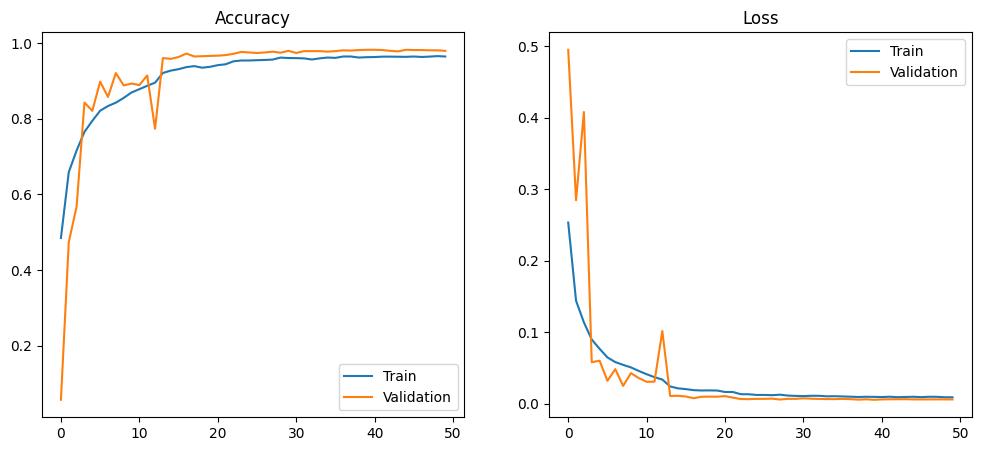

In [19]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])

plt.show()

45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 306ms/step


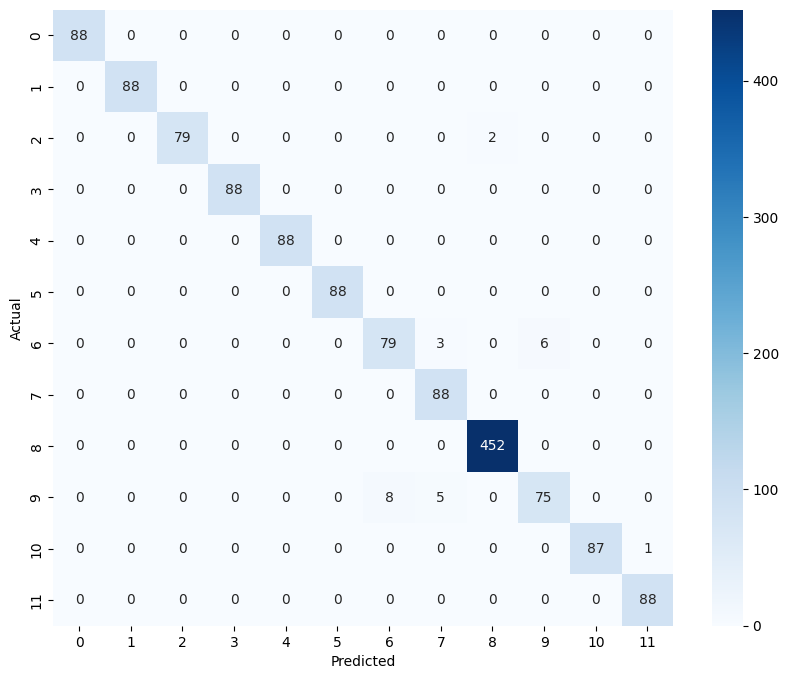

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [3]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Preprocess (VERY IMPORTANT)
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Top 3 predictions
top3 = pred.argsort()[-3:][::-1]

print("🔍 Top Predictions:")
for i in top3:
    print(class_names[i], ":", pred[i])

best_class = class_names[top3[0]]
confidence = pred[top3[0]]

# Confidence check
if confidence < 0.6:
    print("⚠️ Low confidence → unclear image")
else:
    print("✅ Final Prediction:", best_class)

# Show image
plt.imshow(img)
plt.title(f"{best_class} ({confidence:.2f})")
plt.axis('off')
plt.show()

Saving leaf smut.jpeg to leaf smut.jpeg


NameError: name 'model' is not defined

In [31]:
top3 = pred.argsort()[-3:][::-1]

for i in top3:
    print(class_names[i], pred[i])

Sheath Rot 0.70708543
Stem Rot 0.15833235
Tungro 0.11881234


In [24]:
model.save("/content/drive/MyDrive/best_model.h5")

In [8]:
import tensorflow as tf
from tensorflow.keras.models import load_model

# Define focal loss (only if you used it during training)
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        pt = tf.exp(-ce)
        return alpha * (1 - pt)**gamma * ce
    return loss

# Load model
model = load_model(
    "/content/drive/MyDrive/rice_leaf_hybrid_model.h5",
    custom_objects={'loss': focal_loss()}
)

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    "/content/drive/MyDrive/RiceLeafDisease12classes/validation",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

class_names = list(val_generator.class_indices.keys())
print("Classes:", class_names)

Found 1413 images belonging to 12 classes.
Classes: ['Hispa', 'Ragged Stunt Virus', 'Sheath Rot', 'Stem Rot', 'Tungro', 'bacterial_leaf_blight', 'brown_spot', 'healthy', 'irrelevant_pics', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot']


Saving Screenshot 2026-04-24 at 00.07.37.png to Screenshot 2026-04-24 at 00.07.37.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
🔍 Top Predictions:
Sheath Rot : 0.51582956
irrelevant_pics : 0.27386016
Stem Rot : 0.091080405
⚠️ Low confidence — unclear image


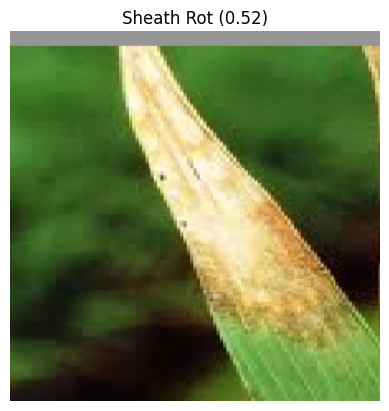

In [10]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Preprocess (VERY IMPORTANT)
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Top 3 predictions
top3 = pred.argsort()[-3:][::-1]

print("🔍 Top Predictions:")
for i in top3:
    print(class_names[i], ":", pred[i])

# Final result
best_class = class_names[top3[0]]
confidence = pred[top3[0]]

if confidence < 0.6:
    print("⚠️ Low confidence — unclear image")
else:
    print("✅ Final Prediction:", best_class)

# Show image
plt.imshow(img)
plt.title(f"{best_class} ({confidence:.2f})")
plt.axis('off')
plt.show()

In [37]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predict on validation (test) data
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_generator.classes

# Accuracy
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_true, y_pred_classes))

# Report
class_names = list(val_generator.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 328ms/step
Accuracy: 0.9823071479122435

Classification Report:

                       precision    recall  f1-score   support

                Hispa       1.00      1.00      1.00        88
   Ragged Stunt Virus       1.00      1.00      1.00        88
           Sheath Rot       1.00      0.98      0.99        81
             Stem Rot       1.00      1.00      1.00        88
               Tungro       1.00      1.00      1.00        88
bacterial_leaf_blight       1.00      1.00      1.00        88
           brown_spot       0.91      0.90      0.90        88
              healthy       0.92      1.00      0.96        88
      irrelevant_pics       1.00      1.00      1.00       452
           leaf_blast       0.93      0.85      0.89        88
           leaf_scald       1.00      0.99      0.99        88
    narrow_brown_spot       0.99      1.00      0.99        88

             accuracy                           0.98      1413
            macro av